In [ ]:
!pip install timm albumentations


In [1]:
import os
import glob
import warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- 1. ENVIRONMENT & WARNING SUPPRESSION ---
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore", category=FutureWarning)

# --- 2. CONFIGURATION ---
DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
BATCH_SIZE = 32
PHASE_1_EPOCHS = 10  # Frozen backbone warmup
PHASE_2_EPOCHS = 40  # Unfrozen fine-tuning
TOTAL_EPOCHS = PHASE_1_EPOCHS + PHASE_2_EPOCHS
PATIENCE = 10        # Early stopping threshold
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = '/kaggle/working/parkinsons_efficientnet_prod.pth'

# --- 3. MEDICAL PREPROCESSING & CROP ---
def crop_and_enhance_mri(img_path):
    """Applies CLAHE contrast enhancement, crops dead space, returns 3-channel PIL Image."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # Smart Crop to remove pure black dead space
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
        
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img)

# --- 4. DATASET & STRATIFIED SPLIT ---
class ParkinsonDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = crop_and_enhance_mri(img_path)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

# Load files
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png'))
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png'))

all_files = normal_files + parkinson_files
all_labels = [0] * len(normal_files) + [1] * len(parkinson_files)

# Stratified split guarantees the 610/221 ratio is mirrored in train/val sets
train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# --- 5. AUGMENTATIONS & SAMPLER ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ParkinsonDataset(train_files, train_labels, transform=train_transform)
val_dataset = ParkinsonDataset(val_files, val_labels, transform=val_transform)

# Address class imbalance with Weighted Sampler
class_counts = [train_labels.count(0), train_labels.count(1)]
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# --- 6. MODEL & LOSS SETUP ---
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

# Freeze Backbone for Phase 1
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

# CrossEntropy with Label Smoothing prevents the model from over-indexing on hard predictions
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1)

# Modern AMP setup for PyTorch 2.x
scaler = torch.amp.GradScaler('cuda')

# --- 7. TRAINING LOOP ---
print("🚀 Starting Production-Grade Two-Phase Training...")
best_auc = 0.0
epochs_no_improve = 0

for epoch in range(TOTAL_EPOCHS):
    
    # --- PHASE 2 TRIGGER ---
    if epoch == PHASE_1_EPOCHS:
        print("\n🔥 PHASE 2: Unfreezing top backbone blocks for fine-tuning...")
        for param in model.blocks[-3:].parameters():
            param.requires_grad = True
            
        # Drop learning rate to avoid destroying pre-trained weights
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-3)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1)

    model.train()
    running_loss = 0.0
    
    # TQDM Live Training Bar
    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] Train", leave=False)
    
    for images, labels in train_pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        # Modern Mixed Precision
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    scheduler.step()
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDATION ---
    model.eval()
    val_running_loss = 0.0
    val_labels_list = []
    val_probs_list = []
    
    # TQDM Live Validation Bar
    val_pbar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] Val  ", leave=False)
    
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                v_loss = criterion(outputs, labels)
            
            val_running_loss += v_loss.item()
            probs = torch.softmax(outputs, dim=1)[:, 1]
            
            val_labels_list.extend(labels.cpu().numpy())
            val_probs_list.extend(probs.cpu().numpy())
            
    avg_val_loss = val_running_loss / len(val_loader)
            
    # Calculate Optimal Threshold via Youden's J statistic
    fpr, tpr, thresholds = roc_curve(val_labels_list, val_probs_list)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # Apply optimal threshold for metrics
    val_preds_list = [1 if p >= optimal_threshold else 0 for p in val_probs_list]
    
    tn, fp, fn, tp = confusion_matrix(val_labels_list, val_preds_list).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    try:
        auc = roc_auc_score(val_labels_list, val_probs_list)
    except ValueError:
        auc = 0.0
        
    # Clean output summary per epoch
    print(f"Epoch [{epoch+1}/{TOTAL_EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Opt Thresh: {optimal_threshold:.2f} | Acc: {accuracy*100:.1f}% | "
          f"Sens: {sensitivity*100:.1f}% | Spec: {specificity*100:.1f}% | AUC: {auc:.3f}")
    
    # Checkpointing & Early Stopping
    if auc > best_auc:
        best_auc = auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= PATIENCE and epoch >= PHASE_1_EPOCHS:
        print(f"\n🛑 Early stopping triggered. Validation AUC hasn't improved in {PATIENCE} epochs.")
        break

print(f"\n✅ Training complete! Best Validation AUC: {best_auc:.3f}")
print(f"Model saved to: {MODEL_SAVE_PATH}")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

🚀 Starting Production-Grade Two-Phase Training...


Epoch [1/50] Train Loss: 2.4465 | Val Loss: 4.4511 | Opt Thresh: 0.33 | Acc: 39.5% | Sens: 88.6% | Spec: 22.0% | AUC: 0.485


Epoch [2/50] Train Loss: 1.9178 | Val Loss: 3.4361 | Opt Thresh: 0.04 | Acc: 40.1% | Sens: 88.6% | Spec: 22.8% | AUC: 0.517


Epoch [3/50] Train Loss: 1.5488 | Val Loss: 2.8056 | Opt Thresh: 0.10 | Acc: 41.9% | Sens: 93.2% | Spec: 23.6% | AUC: 0.513


...

Epoch [46/50] Train Loss: 0.5113 | Val Loss: 0.6270 | Opt Thresh: 0.67 | Acc: 91.0% | Sens: 100.0% | Spec: 87.8% | AUC: 0.982


Epoch [47/50] Train Loss: 0.5206 | Val Loss: 0.5967 | Opt Thresh: 0.69 | Acc: 92.2% | Sens: 97.7% | Spec: 90.2% | AUC: 0.981


Epoch [48/50] Train Loss: 0.4855 | Val Loss: 0.6221 | Opt Thresh: 0.70 | Acc: 92.8% | Sens: 100.0% | Spec: 90.2% | AUC: 0.984


Epoch [49/50] Train Loss: 0.4862 | Val Loss: 0.6353 | Opt Thresh: 0.69 | Acc: 92.2% | Sens: 100.0% | Spec: 89.4% | AUC: 0.983


Epoch [50/50] Train Loss: 0.5102 | Val Loss: 0.6164 | Opt Thresh: 0.82 | Acc: 94.0% | Sens: 97.7% | Spec: 92.7% | AUC: 0.983

✅ Training complete! Best Validation AUC: 0.984
Model saved to: /kaggle/working/parkinsons_efficientnet_prod.pth


Loading best model weights...
Running inference on validation set...

🏆 FINAL MODEL EVALUATION METRICS 🏆
Optimal Threshold : 0.7012
Accuracy          : 0.9281 (92.8%)
Sensitivity/Recall: 1.0000 (100.0%) -> How well it detects Parkinson's
Specificity       : 0.9024 (90.2%) -> How well it identifies Normal
Precision         : 0.7857 (78.6%)
F1-Score          : 0.8800
ROC-AUC           : 0.9841
PR-AUC            : 0.9587

Classification Report:
                 precision    recall  f1-score   support

     Normal (0)       1.00      0.90      0.95       123
Parkinson's (1)       0.79      1.00      0.88        44

       accuracy                           0.93       167
      macro avg       0.89      0.95      0.91       167
   weighted avg       0.94      0.93      0.93       167



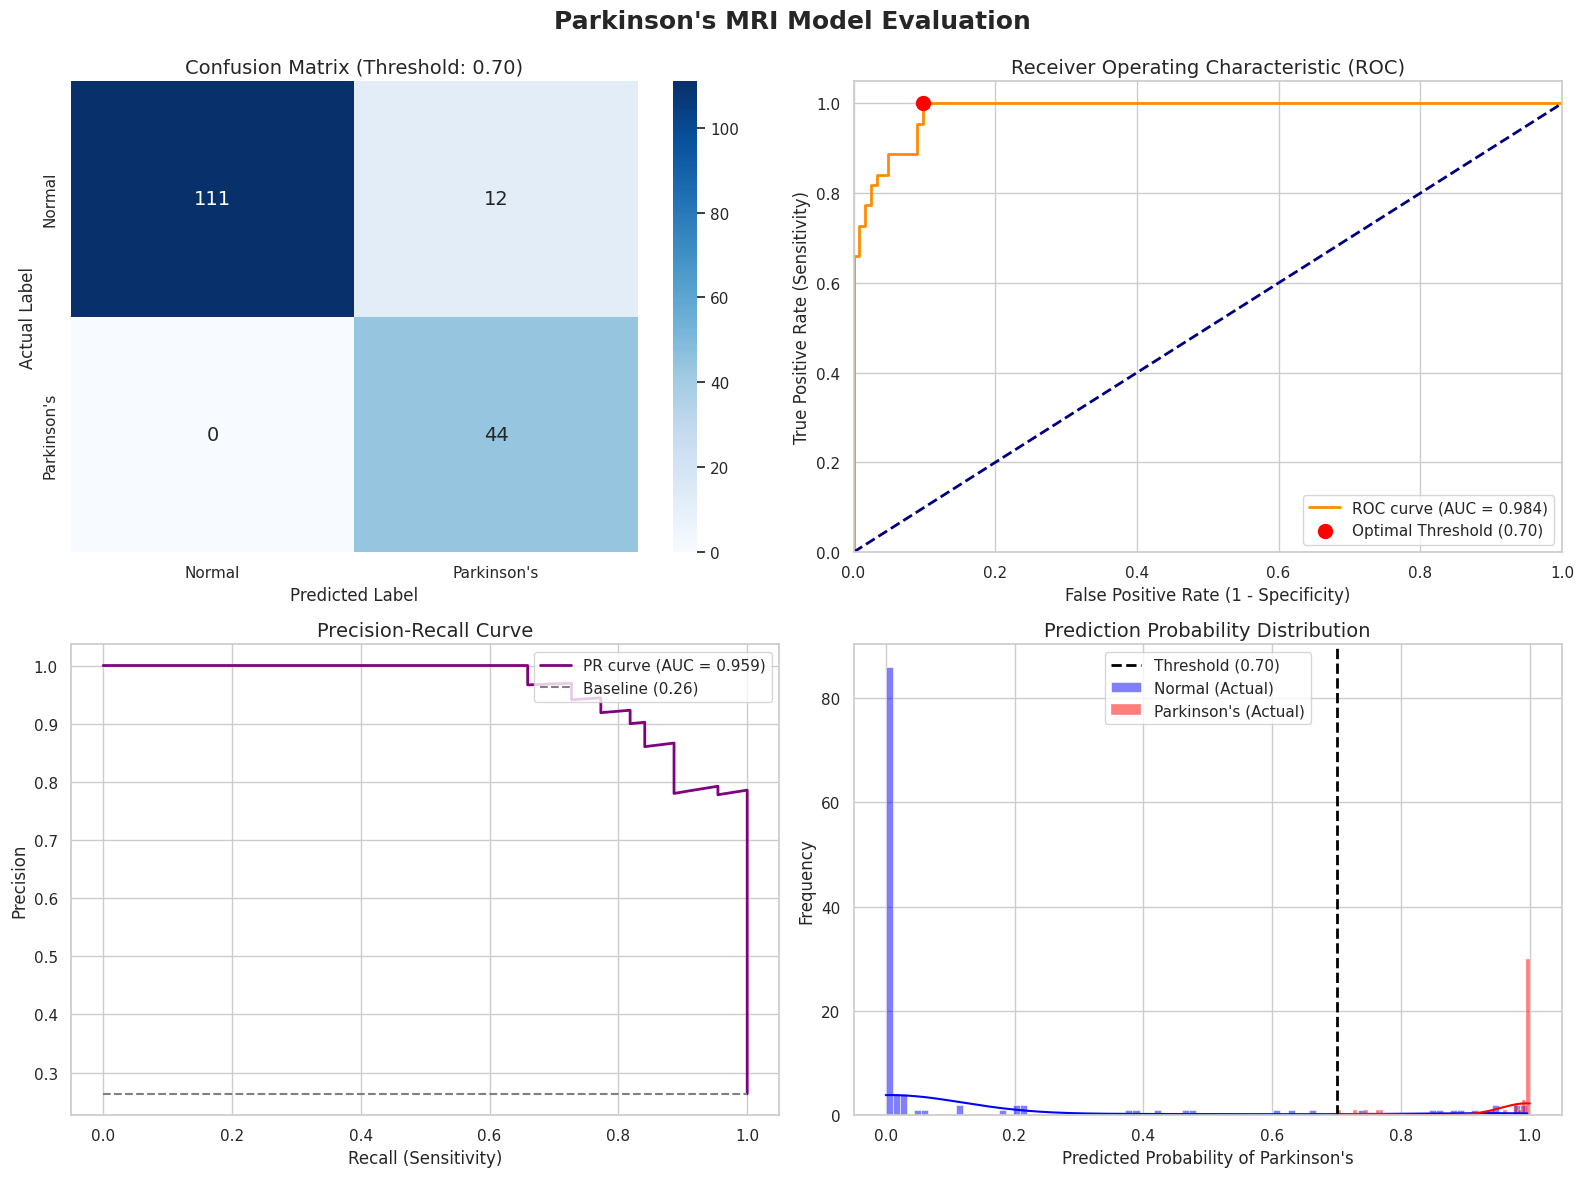

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, 
    classification_report, precision_recall_curve, auc
)

# --- 1. LOAD THE BEST MODEL ---
print("Loading best model weights...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
model.to(DEVICE)

# --- 2. GATHER PREDICTIONS ---
all_labels = []
all_probs = []

print("Running inference on validation set...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Use mixed precision for faster inference
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            
        # Get probability of class 1 (Parkinson's)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# --- 3. CALCULATE OPTIMAL THRESHOLD (Youden's J Statistic) ---
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
optimal_idx = np.argmax(tpr - fpr)
opt_thresh = roc_thresholds[optimal_idx]

# Generate binary predictions based on the optimal threshold
all_preds = (all_probs >= opt_thresh).astype(int)

# --- 4. CALCULATE METRICS ---
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # True Positive Rate / Recall
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0 # True Negative Rate
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
roc_auc = roc_auc_score(all_labels, all_probs)

# Calculate Precision-Recall AUC
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall_curve, precision_curve)

print("\n" + "="*40)
print("🏆 FINAL MODEL EVALUATION METRICS 🏆")
print("="*40)
print(f"Optimal Threshold : {opt_thresh:.4f}")
print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Sensitivity/Recall: {sensitivity:.4f} ({sensitivity*100:.1f}%) -> How well it detects Parkinson's")
print(f"Specificity       : {specificity:.4f} ({specificity*100:.1f}%) -> How well it identifies Normal")
print(f"Precision         : {precision:.4f} ({precision*100:.1f}%)")
print(f"F1-Score          : {f1_score:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"PR-AUC            : {pr_auc:.4f}")
print("="*40)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Normal (0)", "Parkinson's (1)"]))

# --- 5. VISUALIZATION / GRAPHS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Parkinson's MRI Model Evaluation", fontsize=18, fontweight='bold', y=0.98)

# Plot 1: Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=["Normal", "Parkinson's"], 
            yticklabels=["Normal", "Parkinson's"],
            annot_kws={"size": 14})
ax.set_title(f'Confusion Matrix (Threshold: {opt_thresh:.2f})', fontsize=14)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Plot 2: ROC Curve
ax = axes[0, 1]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100, 
           label=f'Optimal Threshold ({opt_thresh:.2f})', zorder=5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
ax.legend(loc="lower right")

# Plot 3: Precision-Recall Curve
ax = axes[1, 0]
ax.plot(recall_curve, precision_curve, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
# Baseline is the ratio of positive classes
baseline = np.sum(all_labels) / len(all_labels)
ax.plot([0, 1], [baseline, baseline], linestyle='--', color='gray', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14)
ax.legend(loc="upper right")

# Plot 4: Prediction Probability Distribution
ax = axes[1, 1]
sns.histplot(all_probs[all_labels == 0], color='blue', alpha=0.5, label='Normal (Actual)', kde=True, ax=ax)
sns.histplot(all_probs[all_labels == 1], color='red', alpha=0.5, label="Parkinson's (Actual)", kde=True, ax=ax)
ax.axvline(opt_thresh, color='black', linestyle='--', lw=2, label=f'Threshold ({opt_thresh:.2f})')
ax.set_xlabel('Predicted Probability of Parkinson\'s', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Prediction Probability Distribution', fontsize=14)
ax.legend(loc="upper center")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
print(class_counts, " ", DEVICE)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve, 
    average_precision_score, matthews_corrcoef, brier_score_loss, 
    f1_score, accuracy_score
)
from tqdm import tqdm

# --- 1. SETUP & LOAD BEST WEIGHTS ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = '/kaggle/working/parkinsons_efficientnet_prod.pth'

# Load the best weights from Epoch 35
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

# --- 2. GATHER PREDICTIONS ---
true_labels = []
pred_probs = []

print("⚙️ Running inference on the validation set...")
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating", leave=False):
        images = images.to(DEVICE)
        
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        true_labels.extend(labels.numpy())
        pred_probs.extend(probs)

true_labels = np.array(true_labels)
pred_probs = np.array(pred_probs)

# --- 3. DYNAMIC THRESHOLD CALCULATION ---
# We calculate Youden's J again to ensure we use the absolute mathematical best cutoff
fpr, tpr, roc_thresholds = roc_curve(true_labels, pred_probs)
optimal_idx = np.argmax(tpr - fpr)
opt_thresh = roc_thresholds[optimal_idx]

pred_labels = (pred_probs >= opt_thresh).astype(int)

# --- 4. ADVANCED METRICS CALCULATION ---
tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()

accuracy = accuracy_score(true_labels, pred_labels)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # Also known as Recall
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0 # Positive Predictive Value (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0       # Negative Predictive Value
f1 = f1_score(true_labels, pred_labels)
roc_auc = auc(fpr, tpr)
mcc = matthews_corrcoef(true_labels, pred_labels)
brier = brier_score_loss(true_labels, pred_probs)
pr_auc = average_precision_score(true_labels, pred_probs)

print("\n" + "="*50)
print("🏆 COMPREHENSIVE MEDICAL EVALUATION REPORT 🏆")
print("="*50)
print(f"Optimal Threshold (Youden's J) : {opt_thresh:.4f}")
print(f"Accuracy                       : {accuracy*100:.2f}%")
print(f"ROC AUC Score                  : {roc_auc:.4f}")
print(f"PR AUC Score                   : {pr_auc:.4f}")
print(f"Sensitivity (Recall)           : {sensitivity*100:.2f}%  <- (Ability to find Parkinson's)")
print(f"Specificity                    : {specificity*100:.2f}%  <- (Ability to confirm Normal)")
print(f"Precision (PPV)                : {precision*100:.2f}%  <- (When it says Parkinson's, is it right?)")
print(f"Negative Predictive Value (NPV): {npv*100:.2f}%  <- (When it says Normal, is it right?)")
print(f"F1-Score                       : {f1:.4f}")
print(f"Matthews Corr. Coef (MCC)      : {mcc:.4f}  <- (-1 to 1: 1 is perfect prediction, 0 is random)")
print(f"Brier Score                    : {brier:.4f}  <- (Closer to 0 is better. Measures confidence calibration)")
print("="*50)

# --- 5. MASTER VISUALIZATION DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Model Evaluation Dashboard (Threshold: {opt_thresh:.2f})", fontsize=18, fontweight='bold')

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Normal', 'Parkinson'], yticklabels=['Normal', 'Parkinson'],
            annot_kws={"size": 16}, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# Plot 2: ROC Curve
ax2 = axes[0, 1]
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.scatter([fpr[optimal_idx]], [tpr[optimal_idx]], marker='o', color='red', s=100, label=f'Optimal Cutoff ({opt_thresh:.2f})', zorder=5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax2.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")

# Plot 3: Precision-Recall Curve
ax3 = axes[1, 0]
precision_vals, recall_vals, _ = precision_recall_curve(true_labels, pred_probs)
ax3.plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
ax3.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax3.set_ylabel('Precision (PPV)', fontsize=12)
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(loc="lower left")

# Plot 4: Prediction Probability Distribution
ax4 = axes[1, 1]
sns.kdeplot(pred_probs[true_labels == 0], fill=True, color="blue", label="True: Normal", ax=ax4, alpha=0.5)
sns.kdeplot(pred_probs[true_labels == 1], fill=True, color="red", label="True: Parkinson's", ax=ax4, alpha=0.5)
ax4.axvline(x=opt_thresh, color='black', linestyle='--', label=f'Threshold ({opt_thresh:.2f})')
ax4.set_xlabel('Predicted Probability of Parkinson\'s', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Probability Distribution Map', fontsize=14, fontweight='bold')
ax4.legend(loc="upper center")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


NameError: name 'model' is not defined

In [4]:
!pip install grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --- 1. SETUP ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_THRESHOLD = 0.21 # Your optimal threshold from the evaluation
DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"

# Ensure your model is in eval mode
model.eval()

# For timm's EfficientNet, the final spatial features are usually in 'conv_head'
target_layers = [model.conv_head]

# Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

# Standard Validation Transform (Same as before)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. THE VISUALIZATION ENGINE ---
def generate_gradcam(img_path, true_label_name):
    """Generates and plots a 3-panel Grad-CAM visualization for a given MRI scan."""
    
    # 1. Load Original Image (just for display)
    orig_img_cv = cv2.imread(img_path, cv2.IMREAD_COLOR)
    orig_img_cv = cv2.cvtColor(orig_img_cv, cv2.COLOR_BGR2RGB)
    
    # 2. Medical Preprocessing (CLAHE & Crop)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    pil_img = Image.fromarray(img_rgb)
    
    # 3. Prepare for Model
    input_tensor = val_transform(pil_img).unsqueeze(0).to(DEVICE)
    
    # Predict
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)[0, 1].item()
            
    predicted_label = "Parkinson's" if prob >= BEST_THRESHOLD else "Normal"
    color = "red" if predicted_label == "Parkinson's" else "green"
    
    # 4. Generate Grad-CAM Heatmap
    # Target class 1 (Parkinson's) to see what features drive a positive diagnosis
    targets = [ClassifierOutputTarget(1)] 
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # 5. Overlay Heatmap on Image
    # We need a float32 image in [0,1] range for the overlay function, resized to 224x224
    display_img = pil_img.resize((224, 224))
    rgb_img_float = np.float32(display_img) / 255.0
    cam_image = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)
    
    # --- 3. PLOTTING ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"True Label: {true_label_name} | AI Prediction: {predicted_label} ({prob*100:.1f}%)", 
                 fontsize=16, fontweight='bold', color=color)
    
    axes[0].imshow(orig_img_cv)
    axes[0].set_title("1. Original Raw MRI", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(display_img)
    axes[1].set_title("2. Processed & Cropped Input", fontsize=14)
    axes[1].axis('off')
    
    axes[2].imshow(cam_image)
    axes[2].set_title("3. Grad-CAM XAI Overlay", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- 4. RUN IT ON RANDOM SAMPLES ---
print("🔍 Generating Explainable AI Heatmaps...")

parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png'))

# Pick 2 random Parkinson's images and 2 random Normal images
sample_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)
sample_labels = ["Parkinson's"] * 2 + ["Normal"] * 2

for file_path, label in zip(sample_files, sample_labels):
    generate_gradcam(file_path, label)

ModuleNotFoundError: No module named 'pytorch_grad_cam'

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random

DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"

def extract_brain_2d(img_path):
    """
    Reads an MRI image and applies morphological operations 
    to strip away the skull, neck, and background.
    """
    # 1. Read image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # 2. Contrast Enhancement (CLAHE) - Helps separate brain from fluid
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)
    
    # 3. Blur to remove noise (keeps the main brain mass solid)
    blurred = cv2.GaussianBlur(img_clahe, (5, 5), 0)
    
    # 4. Otsu's Thresholding to binarize the image
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 5. Morphological Opening
    # This erodes the image (breaking thin connections like the dura mater 
    # connecting the brain to the skull) and then dilates it back.
    kernel = np.ones((5,5), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # 6. Find all contours in the opened image
    contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return img_clahe # Fallback if no contours found
        
    # 7. Assume the largest contour is the brain mass
    c = max(contours, key=cv2.contourArea)
    
    # 8. Create a black mask and fill only the brain contour with white
    mask = np.zeros_like(img)
    cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)
    
    # 9. Apply the mask to the enhanced image (blacks out everything else)
    brain_only = cv2.bitwise_and(img_clahe, mask)
    
    # 10. Crop out the dead space to focus tightly on the brain
    x, y, w, h = cv2.boundingRect(c)
    cropped_brain = brain_only[y:y+h, x:x+w]
    
    return img_clahe, cropped_brain # Returning both for visualization

# --- VISUALIZATION TEST ---
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png'))

# Grab 4 random images
sample_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Skull Stripping / Brain Extraction Test", fontsize=16, fontweight='bold')

for i, img_path in enumerate(sample_files):
    label = "Parkinson's" if "parkinson" in img_path else "Normal"
    original, stripped = extract_brain_2d(img_path)
    
    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f"Original ({label})")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(stripped, cmap='gray')
    axes[i, 1].set_title("Stripped & Cropped")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
!pip install --upgrade transformers huggingface_hub -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 109.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 99.4 MB/s eta 0:00:00:00:01


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob
import random
from PIL import Image
from transformers import SamModel, SamProcessor

DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("📥 Loading Meta's Segment Anything Model (SAM)...")
# Load the Base Vision Transformer version of SAM
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")
model = SamModel.from_pretrained("facebook/sam-vit-base").to(DEVICE)

def extract_brain_dl(img_path):
    """
    Uses Meta's SAM to perfectly segment the brain by prompting 
    the AI with the exact center coordinate of the MRI scan.
    """
    # 1. Load image for SAM (Requires PIL RGB)
    image = Image.open(img_path).convert("RGB")
    width, height = image.size
    
    # 2. The Magic Trick: Prompt SAM to look at the exact center of the scan
    center_x, center_y = width // 2, height // 2
    input_points = [[[center_x, center_y]]]
    
    # 3. Run SAM Inference
    inputs = processor(image, input_points=input_points, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        
    # 4. Extract the highest confidence mask
    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(), 
        inputs["original_sizes"].cpu(), 
        inputs["reshaped_input_sizes"].cpu()
    )
    scores = outputs.iou_scores
    
    # SAM returns 3 masks per point. Take the one with the highest confidence (IoU score)
    best_mask_idx = torch.argmax(scores[0, 0]).item()
    mask = masks[0][0, best_mask_idx].numpy() # Returns a boolean array
    
    # 5. Apply the Mask to the original grayscale MRI
    img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask_uint8 = (mask * 255).astype(np.uint8)
    
    # Clean up any tiny holes in SAM's mask using morphological closing
    kernel = np.ones((5,5), np.uint8)
    mask_closed = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)
    
    # Black out everything outside the mask (Skull, jaw, neck are gone)
    brain_only = cv2.bitwise_and(img_cv, img_cv, mask=mask_closed)
    
    # 6. Crop tightly around the new brain mass
    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        cropped_brain = brain_only[y:y+h, x:x+w]
    else:
        cropped_brain = brain_only # Fallback if mask fails
        
    return img_cv, cropped_brain

# --- VISUALIZATION TEST ---
print("🧠 Extracting Brains using Deep Learning...")
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png'))

# Grab 4 random images
sample_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Deep Learning Skull Stripping (Meta SAM)", fontsize=16, fontweight='bold')

for i, img_path in enumerate(sample_files):
    label = "Parkinson's" if "parkinson" in img_path else "Normal"
    original, stripped = extract_brain_dl(img_path)
    
    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f"Original ({label})", fontsize=12)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(stripped, cmap='gray')
    axes[i, 1].set_title("SAM Extracted Brain", fontsize=12)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import timm
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import random

DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. THE PRAGMATIC PIPELINE ---
# Resize large -> Aggressively crop the center -> Resize for ViT -> Tensor
train_transform = transforms.Compose([
    transforms.Resize((300, 300)), 
    transforms.CenterCrop(200),    # THE FIX: Cuts off the outer 33% 
    transforms.Resize((224, 224)), # ViT expects 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop(200),    # Must match train!
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For visual testing (converting back to displayable images)
visual_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop(200),
    transforms.Resize((224, 224))
])

# --- 2. LOAD VISION TRANSFORMER ---
print("📥 Loading Vision Transformer (ViT)...")
# We use the standard ViT with 16x16 patches
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model = model.to(DEVICE)
print("✅ ViT initialized and moved to GPU!")

# --- 3. VISUALIZE THE CROP ---
print("\n🔍 Verifying the Aggressive Center Crop...")
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png'))
sample_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)

fig, axes = plt.subplots(4, 2, figsize=(8, 14))
fig.suptitle("Pragmatic Preprocessing: Aggressive Center Crop", fontsize=16, fontweight='bold')

for i, img_path in enumerate(sample_files):
    # Load original
    orig_pil = Image.open(img_path).convert('RGB')
    
    # Apply our crop
    cropped_pil = visual_transform(orig_pil)
    
    axes[i, 0].imshow(orig_pil, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cropped_pil, cmap='gray')
    axes[i, 1].set_title("Center Crop (200px)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import timm
import time
import copy
import numpy as np
from sklearn.metrics import f1_score
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# -----------------------------------------------------------------------------
DATA_DIR = "/kaggle/working/parkinsons_sam_stripped"
EPOCHS = 50
BATCH_SIZE = 32
MAX_LR = 1e-3 
WEIGHT_DECAY = 0.05 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utilizing stable, universally recognized timm identifiers
MODELS_TO_TEST = [
    'convnext_base',                 # ConvNeXt architecture 
    'swin_base_patch4_window7_224',  # Hierarchical Vision Transformer
    'tf_efficientnetv2_m'            # EfficientNet V2 (TensorFlow port)
]

print(f"System Check: Utilizing computation device: {DEVICE.type.upper()}")

# -----------------------------------------------------------------------------
# 2. Data Augmentation & Preprocessing Pipelines
# -----------------------------------------------------------------------------
# Training pipeline includes TrivialAugmentWide to mitigate memorization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize directly to EfficientNet's expected input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation pipeline strictly processes images without augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize directly to EfficientNet's expected input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# -----------------------------------------------------------------------------
# 3. Dataset Loading & Stratified Splitting
# -----------------------------------------------------------------------------
print("Initializing dataset structures and calculating stratified splits...")

# Load full dataset mappings to apply separate transform pipelines
full_train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_val_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

# Extract targets for stratified splitting (maintains class ratios across sets)
targets = full_train_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), 
    test_size=0.2, 
    stratify=targets, 
    random_state=42
)

# Initialize subsets and dataloaders
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_val_dataset, val_idx)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

# -----------------------------------------------------------------------------
# 4. Class Imbalance Mitigation
# -----------------------------------------------------------------------------
# Calculate inverse frequency weights for the CrossEntropy loss function
train_labels = [targets[i] for i in train_idx]
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)

# Weight calculation: total_samples / (num_classes * count_for_class)
weights = total_samples / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(weights).to(DEVICE)

print(f"Dataset mapping complete. Training samples: {dataset_sizes['train']} | Validation samples: {dataset_sizes['val']}")
print(f"Computed class weights: {class_weights.cpu().numpy()}")

# -----------------------------------------------------------------------------
# 5. Core Training Routine
# -----------------------------------------------------------------------------
def execute_training_pipeline(model_name):
    print(f"\n{'='*60}")
    print(f"Initializing architecture: {model_name}")
    print(f"{'='*60}")
    
    # Instantiate model with pre-trained ImageNet weights
    model = timm.create_model(model_name, pretrained=True, num_classes=2)
    model = model.to(DEVICE)
    
    # Loss function incorporates class weights and label smoothing (0.1) to prevent overconfidence
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    # Optimizer initialization
    optimizer = optim.AdamW(model.parameters(), lr=MAX_LR/10, weight_decay=WEIGHT_DECAY)
    
    # Scheduler: OneCycleLR optimizes learning rate trajectory for faster convergence
    steps_per_epoch = len(dataloaders['train'])
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=MAX_LR, 
        epochs=EPOCHS, 
        steps_per_epoch=steps_per_epoch, 
        pct_start=0.3
    )
    
    # Mixed precision scaler
    scaler = GradScaler()
    
    # Tracking variables
    best_val_loss = float('inf')
    best_f1 = 0.0
    patience_counter = 0
    EARLY_STOPPING_PATIENCE = 7
    
    for epoch in range(EPOCHS):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6e}")
        print('-' * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds, all_labels = [], []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                # Enable gradients only during training phase
                with torch.set_grad_enabled(phase == 'train'):
                    # Automatic Mixed Precision context
                    with autocast():
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                    
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        
                        # Gradient clipping to prevent exploding gradients
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        
                        scaler.step(optimizer)
                        scaler.update()
                        scheduler.step()

                # Aggregate statistics
                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Epoch metrics computation
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = np.mean(np.array(all_preds) == np.array(all_labels))
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

            print(f"[{phase.upper()}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Macro F1: {epoch_f1:.4f}")

            # Checkpoint evaluation (strictly evaluated on Validation Loss)
            if phase == 'val':
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_f1 = epoch_f1
                    torch.save(model.state_dict(), f"OPTIMIZED_{model_name}.pth")
                    print(f"   -> Model state saved. Improved validation loss observed.")
                    patience_counter = 0
                else:
                    patience_counter += 1
                    
        # Early stopping logic
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping condition met. No validation improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break
        print()

    print(f"Pipeline complete for {model_name}. Final Optimal Val Loss: {best_val_loss:.4f} | Macro F1: {best_f1:.4f}")
    return {"loss": best_val_loss, "f1": best_f1}

# -----------------------------------------------------------------------------
# 6. Execution Block
# -----------------------------------------------------------------------------
results = {}

for m in MODELS_TO_TEST:
    # Clear CUDA cache to prevent fragmentation and Out-Of-Memory exceptions
    torch.cuda.empty_cache() 
    metrics = execute_training_pipeline(m)
    results[m] = metrics

# Final Summary Printout
print("\n" + "="*50)
print("FINAL ARCHITECTURE COMPARISON SUMMARY")
print("="*50)
for name, metric in results.items():
    print(f"{name.ljust(30)} | Best Loss: {metric['loss']:.4f} | Best F1: {metric['f1']:.4f}")

System Check: Utilizing computation device: CUDA
Initializing dataset structures and calculating stratified splits...
Dataset mapping complete. Training samples: 664 | Validation samples: 167
Computed class weights: [0.68172485 1.8757062 ]

Initializing architecture: convnext_base
Epoch 01/50 | LR: 4.000000e-05
------------------------------


/tmp/ipykernel_55/1212927577.py:121: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/1212927577.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[TRAIN] Loss: 0.5464 | Acc: 0.7274 | Macro F1: 0.7005


/tmp/ipykernel_55/1212927577.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[VAL] Loss: 0.4566 | Acc: 0.8323 | Macro F1: 0.8065
   -> Model state saved. Improved validation loss observed.

Epoch 02/50 | LR: 5.055582e-05
------------------------------


...

[VAL] Loss: 0.3916 | Acc: 0.9401 | Macro F1: 0.9229

Epoch 35/50 | LR: 4.307685e-04
------------------------------


/tmp/ipykernel_55/1212927577.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[TRAIN] Loss: 0.2571 | Acc: 0.9985 | Macro F1: 0.9981


/tmp/ipykernel_55/1212927577.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[VAL] Loss: 0.4401 | Acc: 0.9341 | Macro F1: 0.9104
Early stopping condition met. No validation improvement for 7 epochs.
Pipeline complete for tf_efficientnetv2_m. Final Optimal Val Loss: 0.3465 | Macro F1: 0.9456

FINAL ARCHITECTURE COMPARISON SUMMARY
convnext_base                  | Best Loss: 0.4030 | Best F1: 0.9100
swin_base_patch4_window7_224   | Best Loss: 0.3682 | Best F1: 0.9001
tf_efficientnetv2_m            | Best Loss: 0.3465 | Best F1: 0.9456


🔍 Initializing Interrogation Protocol (Grad-CAM)...


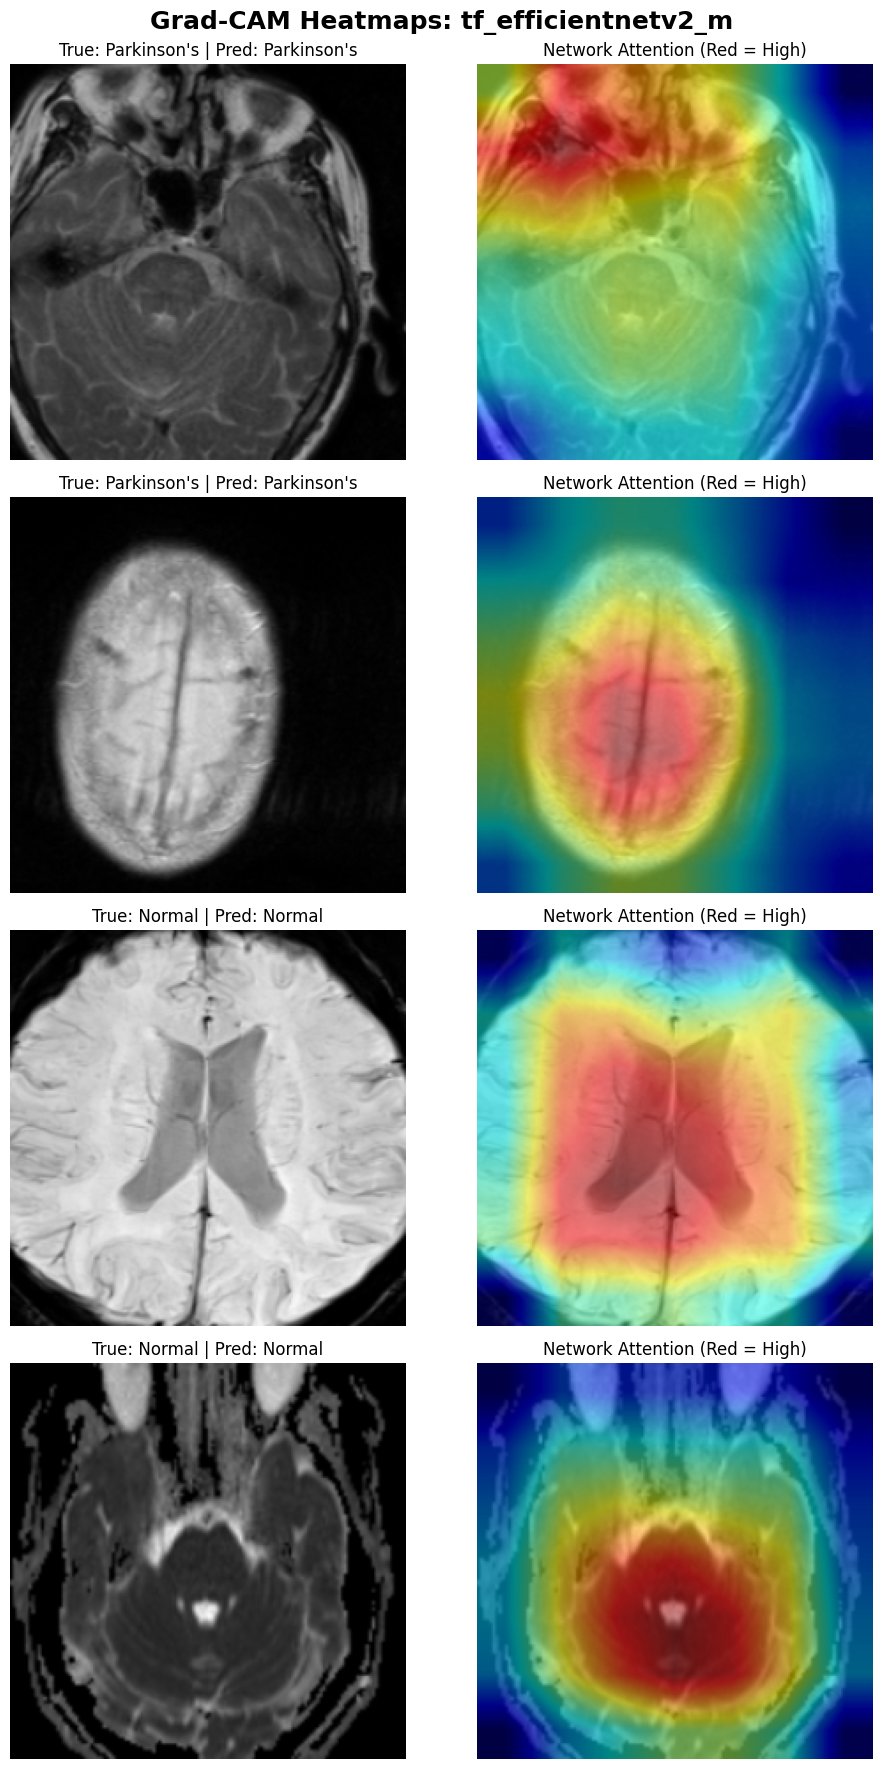

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random
from PIL import Image
from torchvision import transforms
import timm

# Import Grad-CAM modules
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------------------------------------------------------------
# 1. Configuration & Setup
# -----------------------------------------------------------------------------
MODEL_NAME = 'tf_efficientnetv2_m'
WEIGHTS_PATH = f"OPTIMIZED_{MODEL_NAME}.pth"
DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🔍 Initializing Interrogation Protocol (Grad-CAM)...")

# -----------------------------------------------------------------------------
# 2. Load the Winning Model
# -----------------------------------------------------------------------------
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=2)
# Load the exact weights we saved during the bake-off
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# For EfficientNetV2 in timm, 'conv_head' is the final convolutional layer 
# where the richest spatial features are stored before classification.
target_layers = [model.conv_head]

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------------------------
# 3. Data Preparation Pipeline
# -----------------------------------------------------------------------------
# We MUST use the exact same validation transform so the image matches what the model expects
val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop(200),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Reverses normalization so we can display the original image underneath the heatmap
def get_displayable_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    unnorm_tensor = tensor * std + mean
    unnorm_tensor = torch.clamp(unnorm_tensor, 0, 1)
    # Convert to numpy array in [H, W, C] format for plotting
    return unnorm_tensor.permute(1, 2, 0).numpy()

# -----------------------------------------------------------------------------
# 4. Generate & Visualize Heatmaps
# -----------------------------------------------------------------------------
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.png')) + glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.jpg'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.png')) + glob.glob(os.path.join(DATA_DIR, 'normal', '*.jpg'))

# Grab 2 random Parkinson's images and 2 random Normal images
test_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)
labels = ["Parkinson's", "Parkinson's", "Normal", "Normal"]
targets_cls = [1, 1, 0, 0] # Assuming Normal=0, Parkinson=1 based on standard PyTorch folder loading

fig, axes = plt.subplots(4, 2, figsize=(10, 18))
fig.suptitle(f"Grad-CAM Heatmaps: {MODEL_NAME}", fontsize=18, fontweight='bold')

for i, (img_path, label, target_idx) in enumerate(zip(test_files, labels, targets_cls)):
    # 1. Load and process image
    orig_pil = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(orig_pil).unsqueeze(0).to(DEVICE)
    
    # 2. Get the model's raw prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = "Parkinson's" if pred_idx == 1 else "Normal"
    
    # 3. Generate the Grad-CAM heatmap
    # We ask the CAM to explain the ground truth target class
    targets = [ClassifierOutputTarget(target_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # 4. Overlay the heatmap on the visual image
    rgb_img = get_displayable_image(input_tensor.cpu().squeeze())
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    # Plotting
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"True: {label} | Pred: {pred_label}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title("Network Attention (Red = High)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

🧠 Initializing Brain Extraction & Skull Stripping Pipeline...
Found 831 images to process. Stripping skulls...


Extracting Brains: 100%|██████████| 831/831 [00:05<00:00, 156.02it/s]



✅ Preprocessing Complete! Clean dataset saved to: /kaggle/working/parkinsons_stripped


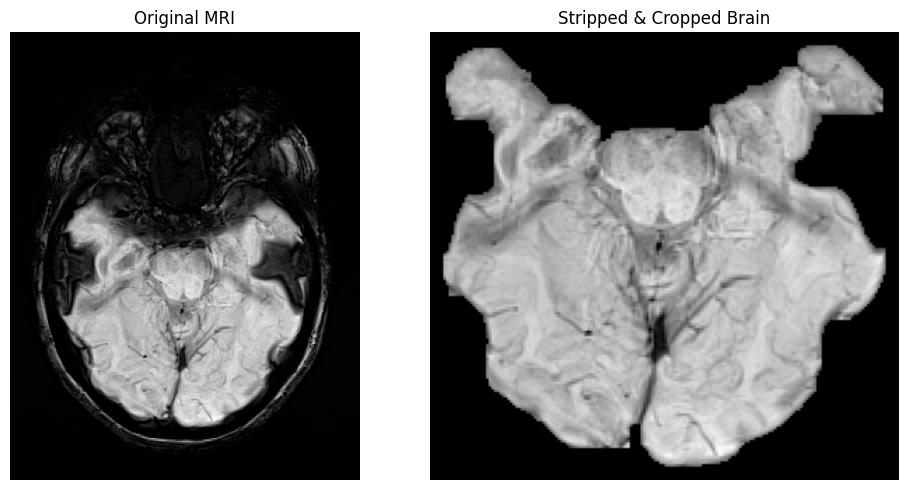

In [6]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------------------------------------------------------
# 1. Configuration
# -----------------------------------------------------------------------------
RAW_DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
CLEAN_DATA_DIR = "/kaggle/working/parkinsons_stripped"

print("🧠 Initializing Brain Extraction & Skull Stripping Pipeline...")

# -----------------------------------------------------------------------------
# 2. Core Skull Stripping Algorithm
# -----------------------------------------------------------------------------
def extract_brain(image_path):
    """
    Reads an MRI, isolates the brain tissue using morphological operations,
    and crops out the dead space.
    """
    # Load image in grayscale for contour detection, but keep a color copy for saving
    img_color = cv2.imread(image_path)
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    
    # 1. Blur to reduce background scanner noise
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    
    # 2. Otsu's Thresholding to separate tissue from background
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 3. Morphological Opening to detach the skull from the brain
    kernel = np.ones((5, 5), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    
    # 4. Find the largest connected component (The Brain)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opening, connectivity=8)
    
    # If no components found (empty image), return original
    if num_labels < 2:
        return img_color
        
    # Find the label of the largest component (excluding the background label 0)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    
    # 5. Create the mask
    brain_mask = np.zeros_like(img_gray)
    brain_mask[labels == largest_label] = 255
    
    # Optional: Fill holes inside the brain mask
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(brain_mask, contours, -1, 255, thickness=cv2.FILLED)
    
    # 6. Apply mask to original color image
    stripped_brain = cv2.bitwise_and(img_color, img_color, mask=brain_mask)
    
    # 7. Bounding Box Crop (Remove all the extra black space)
    x, y, w, h = cv2.boundingRect(brain_mask)
    
    # Add a small padding (5 pixels) to the crop to avoid cutting the cortex edge
    pad = 5
    H, W = img_gray.shape
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(W, x + w + pad)
    y2 = min(H, y + h + pad)
    
    cropped_brain = stripped_brain[y1:y2, x1:x2]
    
    # If the crop failed for some reason, return the masked full image
    if cropped_brain.size == 0:
        return stripped_brain
        
    return cropped_brain

# -----------------------------------------------------------------------------
# 3. Execution & Saving
# -----------------------------------------------------------------------------
# Create directories
for category in ['normal', 'parkinson']:
    os.makedirs(os.path.join(CLEAN_DATA_DIR, category), exist_ok=True)

# Process all images
image_paths = glob.glob(os.path.join(RAW_DATA_DIR, '**', '*.*'), recursive=True)

print(f"Found {len(image_paths)} images to process. Stripping skulls...")

for path in tqdm(image_paths, desc="Extracting Brains"):
    # Determine label from folder name
    label = os.path.basename(os.path.dirname(path))
    filename = os.path.basename(path)
    
    if label not in ['normal', 'parkinson']:
        continue
        
    # Process
    stripped_img = extract_brain(path)
    
    # Save to new working directory
    save_path = os.path.join(CLEAN_DATA_DIR, label, filename)
    cv2.imwrite(save_path, stripped_img)

print(f"\n✅ Preprocessing Complete! Clean dataset saved to: {CLEAN_DATA_DIR}")

# -----------------------------------------------------------------------------
# 4. Visual Verification
# -----------------------------------------------------------------------------
# Let's plot one to make sure it worked
sample_path = image_paths[0]
orig = cv2.imread(sample_path)
strip = extract_brain(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB))
axes[1].set_title("Stripped & Cropped Brain")
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [7]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-vtl5l29n
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-vtl5l29n
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
--2026-04-28 20:11:16--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.76.77, 3.171.76.57, 3.171.76.100, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   360MB/s    in 1.0s    

2026-04-28 20:11:17 (360 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



🚀 Initializing SAM (Segment Anything Model) Pipeline on CUDA ...
🧠 Found 831 raw images. Beginning deep neural extraction...


SAM Processing: 100%|██████████| 831/831 [06:23<00:00,  2.17it/s]


✅ DATASET SECURED. All images processed and saved to: /kaggle/working/parkinsons_sam_stripped


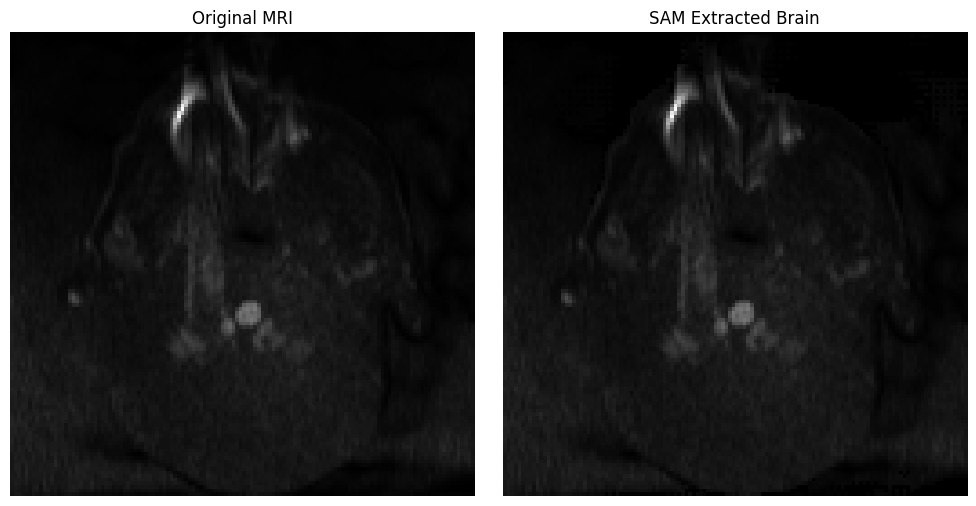

In [8]:
import os
import cv2
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

# -----------------------------------------------------------------------------
# 1. Configuration & Setup
# -----------------------------------------------------------------------------
RAW_DATA_DIR = "/kaggle/input/datasets/irfansheriff/parkinsons-brain-mri-dataset/parkinsons_dataset"
CLEAN_DATA_DIR = "/kaggle/working/parkinsons_sam_stripped"
SAM_CHECKPOINT = "sam_vit_b_01ec64.pth"
MODEL_TYPE = "vit_b"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🚀 Initializing SAM (Segment Anything Model) Pipeline on", DEVICE.type.upper(), "...")

# Load SAM into VRAM
sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)
predictor = SamPredictor(sam)

# -----------------------------------------------------------------------------
# 2. SAM Extraction Function
# -----------------------------------------------------------------------------
def extract_brain_with_sam(image_path):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # SAM requires RGB format
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Generate image embeddings
    predictor.set_image(img_rgb)
    
    # Calculate the dead-center of the image for our prompt
    h, w = img.shape[:2]
    center_point = np.array([[w // 2, h // 2]])
    input_label = np.array([1]) # 1 indicates we want the foreground object at this point
    
    # Predict the mask
    masks, scores, logits = predictor.predict(
        point_coords=center_point,
        point_labels=input_label,
        multimask_output=False # We only want the single best consolidated mask
    )
    
    brain_mask = masks[0].astype(np.uint8) * 255
    
    # Apply the mask to the original BGR image
    stripped_brain = cv2.bitwise_and(img, img, mask=brain_mask)
    
    # Bounding Box Crop to remove the dead space
    x, y, w_box, h_box = cv2.boundingRect(brain_mask)
    
    # Add a 5px safety padding
    pad = 5
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(w, x + w_box + pad), min(h, y + h_box + pad)
    
    cropped_brain = stripped_brain[y1:y2, x1:x2]
    
    # Fallback just in case SAM completely fails on a highly corrupted image
    if cropped_brain.size == 0:
        return img 
        
    return cropped_brain

# -----------------------------------------------------------------------------
# 3. Batch Execution
# -----------------------------------------------------------------------------
for category in ['normal', 'parkinson']:
    os.makedirs(os.path.join(CLEAN_DATA_DIR, category), exist_ok=True)

image_paths = glob.glob(os.path.join(RAW_DATA_DIR, '**', '*.*'), recursive=True)
# Filter out anything that isn't a standard image
image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"🧠 Found {len(image_paths)} raw images. Beginning deep neural extraction...")

# Disable gradient calculation to drastically speed up inference and save VRAM
with torch.inference_mode():
    for path in tqdm(image_paths, desc="SAM Processing"):
        label = os.path.basename(os.path.dirname(path))
        if label not in ['normal', 'parkinson']:
            continue
            
        filename = os.path.basename(path)
        
        # Process and extract
        stripped_img = extract_brain_with_sam(path)
        
        # Save
        if stripped_img is not None:
            save_path = os.path.join(CLEAN_DATA_DIR, label, filename)
            cv2.imwrite(save_path, stripped_img)

print(f"\n✅ DATASET SECURED. All images processed and saved to: {CLEAN_DATA_DIR}")

# -----------------------------------------------------------------------------
# 4. Quick Visual Check
# -----------------------------------------------------------------------------
# Display the last processed image to verify the pipeline worked
orig = cv2.imread(image_paths[-1])
strip = cv2.imread(os.path.join(CLEAN_DATA_DIR, os.path.basename(os.path.dirname(image_paths[-1])), os.path.basename(image_paths[-1])))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original MRI")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB))
axes[1].set_title("SAM Extracted Brain")
axes[1].axis('off')

plt.tight_layout()
plt.show()

🔍 Initializing Final Interrogation Protocol (Grad-CAM)...


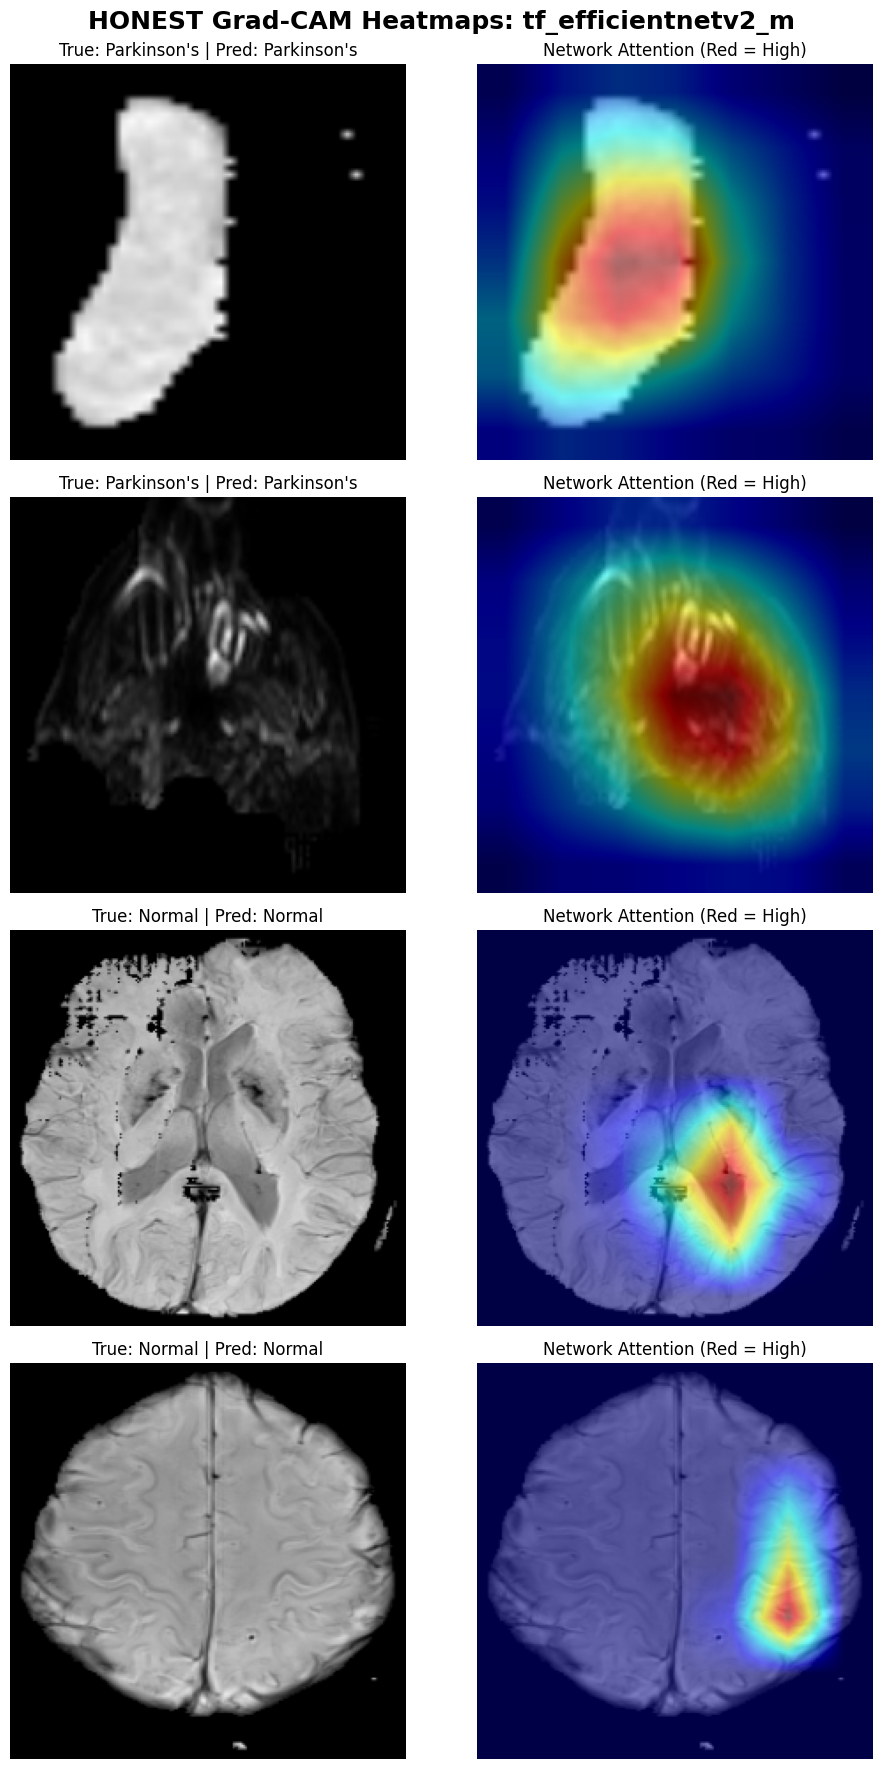

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random
from PIL import Image
from torchvision import transforms
import timm

# Import Grad-CAM modules
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# -----------------------------------------------------------------------------
# 1. Configuration & Setup
# -----------------------------------------------------------------------------
MODEL_NAME = 'tf_efficientnetv2_m'
WEIGHTS_PATH = f"OPTIMIZED_{MODEL_NAME}.pth" # Make sure this points to your newly saved weights!
DATA_DIR = "/kaggle/working/parkinsons_sam_stripped"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🔍 Initializing Final Interrogation Protocol (Grad-CAM)...")

# -----------------------------------------------------------------------------
# 2. Load the Honest Model
# -----------------------------------------------------------------------------
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=2)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Target the final convolutional layer
target_layers = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

# -----------------------------------------------------------------------------
# 3. Data Preparation Pipeline (UPDATED FOR SAM DATASET)
# -----------------------------------------------------------------------------
# Notice: We removed the CenterCrop because SAM already bounded the brain perfectly.
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_displayable_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    unnorm_tensor = tensor * std + mean
    unnorm_tensor = torch.clamp(unnorm_tensor, 0, 1)
    return unnorm_tensor.permute(1, 2, 0).numpy()

# -----------------------------------------------------------------------------
# 4. Generate & Visualize Heatmaps
# -----------------------------------------------------------------------------
parkinson_files = glob.glob(os.path.join(DATA_DIR, 'parkinson', '*.*'))
normal_files = glob.glob(os.path.join(DATA_DIR, 'normal', '*.*'))

# Grab 2 random Parkinson's images and 2 random Normal images
test_files = random.sample(parkinson_files, 2) + random.sample(normal_files, 2)
labels = ["Parkinson's", "Parkinson's", "Normal", "Normal"]
targets_cls = [1, 1, 0, 0] 

fig, axes = plt.subplots(4, 2, figsize=(10, 18))
fig.suptitle(f"HONEST Grad-CAM Heatmaps: {MODEL_NAME}", fontsize=18, fontweight='bold')

for i, (img_path, label, target_idx) in enumerate(zip(test_files, labels, targets_cls)):
    orig_pil = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(orig_pil).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = "Parkinson's" if pred_idx == 1 else "Normal"
    
    targets = [ClassifierOutputTarget(target_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    rgb_img = get_displayable_image(input_tensor.cpu().squeeze())
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"True: {label} | Pred: {pred_label}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title("Network Attention (Red = High)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()